# Sprint 6: Presentation-Quality Figures

Regenerates 8 polished figures from the EDA and pricing model notebooks with:
- New colorblind-safe palette (blue / crimson / teal)
- 300 dpi for print and slide decks
- Consistent typography (larger fonts for projection)
- Depop caveat footnotes on all figures showing Depop data

Original figures in `figures/` are untouched. Polished versions saved to `figures/final/`.

**Skipped (internal-only):** `target_distribution.png`, `residual_distribution.png`, `predicted_vs_actual_by_category.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split

# --- Presentation style ---
PLATFORM_COLORS = {"eBay": "#3B82F6", "Poshmark": "#DC2626", "Depop": "#06B6D4"}
PLATFORM_ORDER = ["eBay", "Poshmark", "Depop"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.facecolor": "white",
})
sns.set_theme(style="whitegrid", font_scale=1.1)

FIGURES_DIR = Path("figures/final")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEPOP_FOOTNOTE = "* Depop reflects listed prices, not confirmed sold prices"


def save_fig(name, fig=None):
    target = fig or plt.gcf()
    target.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight", facecolor="white")
    plt.show()


def add_depop_footnote(fig):
    fig.text(0.99, 0.01, DEPOP_FOOTNOTE,
             ha="right", va="bottom", fontsize=9, fontstyle="italic", color="#666")


print("Style configured. Output:", FIGURES_DIR)

Style configured. Output: figures/final


In [2]:
# --- Load data ---
df = pd.read_csv("../data/cleaned/all_platforms.csv")

# Compute derived columns (same as EDA notebook)
PLATFORM_FEES = {"Poshmark": 0.20, "eBay": 0.13, "Depop": 0.10}
SHIPPING_COST = 5.99
TIME_PER_ITEM_MIN = 35

df["platform_fee_rate"] = df["platform"].map(PLATFORM_FEES)
df["net_profit"] = df["final_sale_price"] * (1 - df["platform_fee_rate"]) - SHIPPING_COST
df["effective_hourly_rate"] = (df["net_profit"] / TIME_PER_ITEM_MIN) * 60
df["dont_sell"] = df["effective_hourly_rate"] < 15.00

categories = sorted(df["item_category"].unique())
print(f"Loaded {len(df)} rows, {len(categories)} categories")

Loaded 5919 rows, 8 categories


In [3]:
# --- Load model + reproduce test set (for predicted_vs_actual) ---
import re

model = joblib.load("../models/pricing_model.joblib")
config = joblib.load("../models/feature_config.joblib")

LUXURY_BRANDS = config["LUXURY_BRANDS"]
PREMIUM_BRANDS = config["PREMIUM_BRANDS"]
TOP_30_BRANDS = config["TOP_30_BRANDS"]
CONDITION_MAP = config["CONDITION_MAP"]
ALL_FEATURES = config["ALL_FEATURES"]

SIZE_PATTERN = re.compile(r"\b(?:XXS|XS|S|M|L|XL|XXL|XXXL|\d{1,2}(?:\.\d)?)\b", re.IGNORECASE)
NWT_PATTERN = re.compile(r"\b(?:NWT|BNWT|new with tags)\b", re.IGNORECASE)


def engineer_features(frame):
    out = frame.copy()
    out["brand"] = out["brand"].fillna("Unknown")
    def get_brand_tier(b):
        if b in LUXURY_BRANDS: return "luxury"
        if b in PREMIUM_BRANDS: return "premium"
        if b != "Unknown": return "known"
        return "unknown"
    out["brand_tier"] = out["brand"].apply(get_brand_tier)
    out["brand_top30"] = out["brand"].apply(lambda b: b if b in TOP_30_BRANDS else "Other")
    out["condition"] = out["condition"].fillna("Unknown")
    out["condition_ordinal"] = out["condition"].map(CONDITION_MAP).fillna(0).astype(int)
    title_lower = out["title"].str.lower()
    out["title_length"] = out["title"].str.len()
    out["title_word_count"] = out["title"].str.split().str.len()
    out["title_has_brand"] = ((out["brand"] != "Unknown") & out.apply(lambda r: r["brand"].lower() in r["title"].lower(), axis=1)).astype(int)
    out["title_has_size"] = title_lower.str.contains(SIZE_PATTERN).astype(int)
    out["title_has_vintage"] = title_lower.str.contains("vintage").astype(int)
    out["title_has_nwt"] = title_lower.str.contains(NWT_PATTERN).astype(int)
    out["platform_category"] = out["platform"] + "_" + out["item_category"]
    return out


# Reproduce train/test split (same random_state as notebook 02)
df_model = engineer_features(df)
y = np.log1p(df_model["final_sale_price"])
X = df_model
strat = df_model["platform"] + "_" + df_model["item_category"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=strat)

y_test_raw = np.expm1(y_test)
preds_log = model.predict(X_test[ALL_FEATURES])
preds_raw = np.clip(np.expm1(preds_log), 1.0, None)

test_eval = X_test.copy()
test_eval["y_true"] = y_test_raw.values
test_eval["y_pred"] = preds_raw

# Feature importances (pipeline steps are named 'preprocessor' and 'model')
xgb_model = model.named_steps["model"]
preprocessor = model.named_steps["preprocessor"]
all_feature_names = preprocessor.get_feature_names_out()

print(f"Test set: {len(test_eval)} rows, {len(all_feature_names)} features")

Test set: 1184 rows, 76 features


## Figure 1: Price Distribution by Platform per Category

/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_85153/22481815.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cat_df, x="platform", y="final_sale_price", ax=axes[i],
/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_85153/22481815.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cat_df, x="platform", y="final_sale_price", ax=axes[i],
/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_85153/22481815.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cat_df, x="platform", y="final_sale_price"

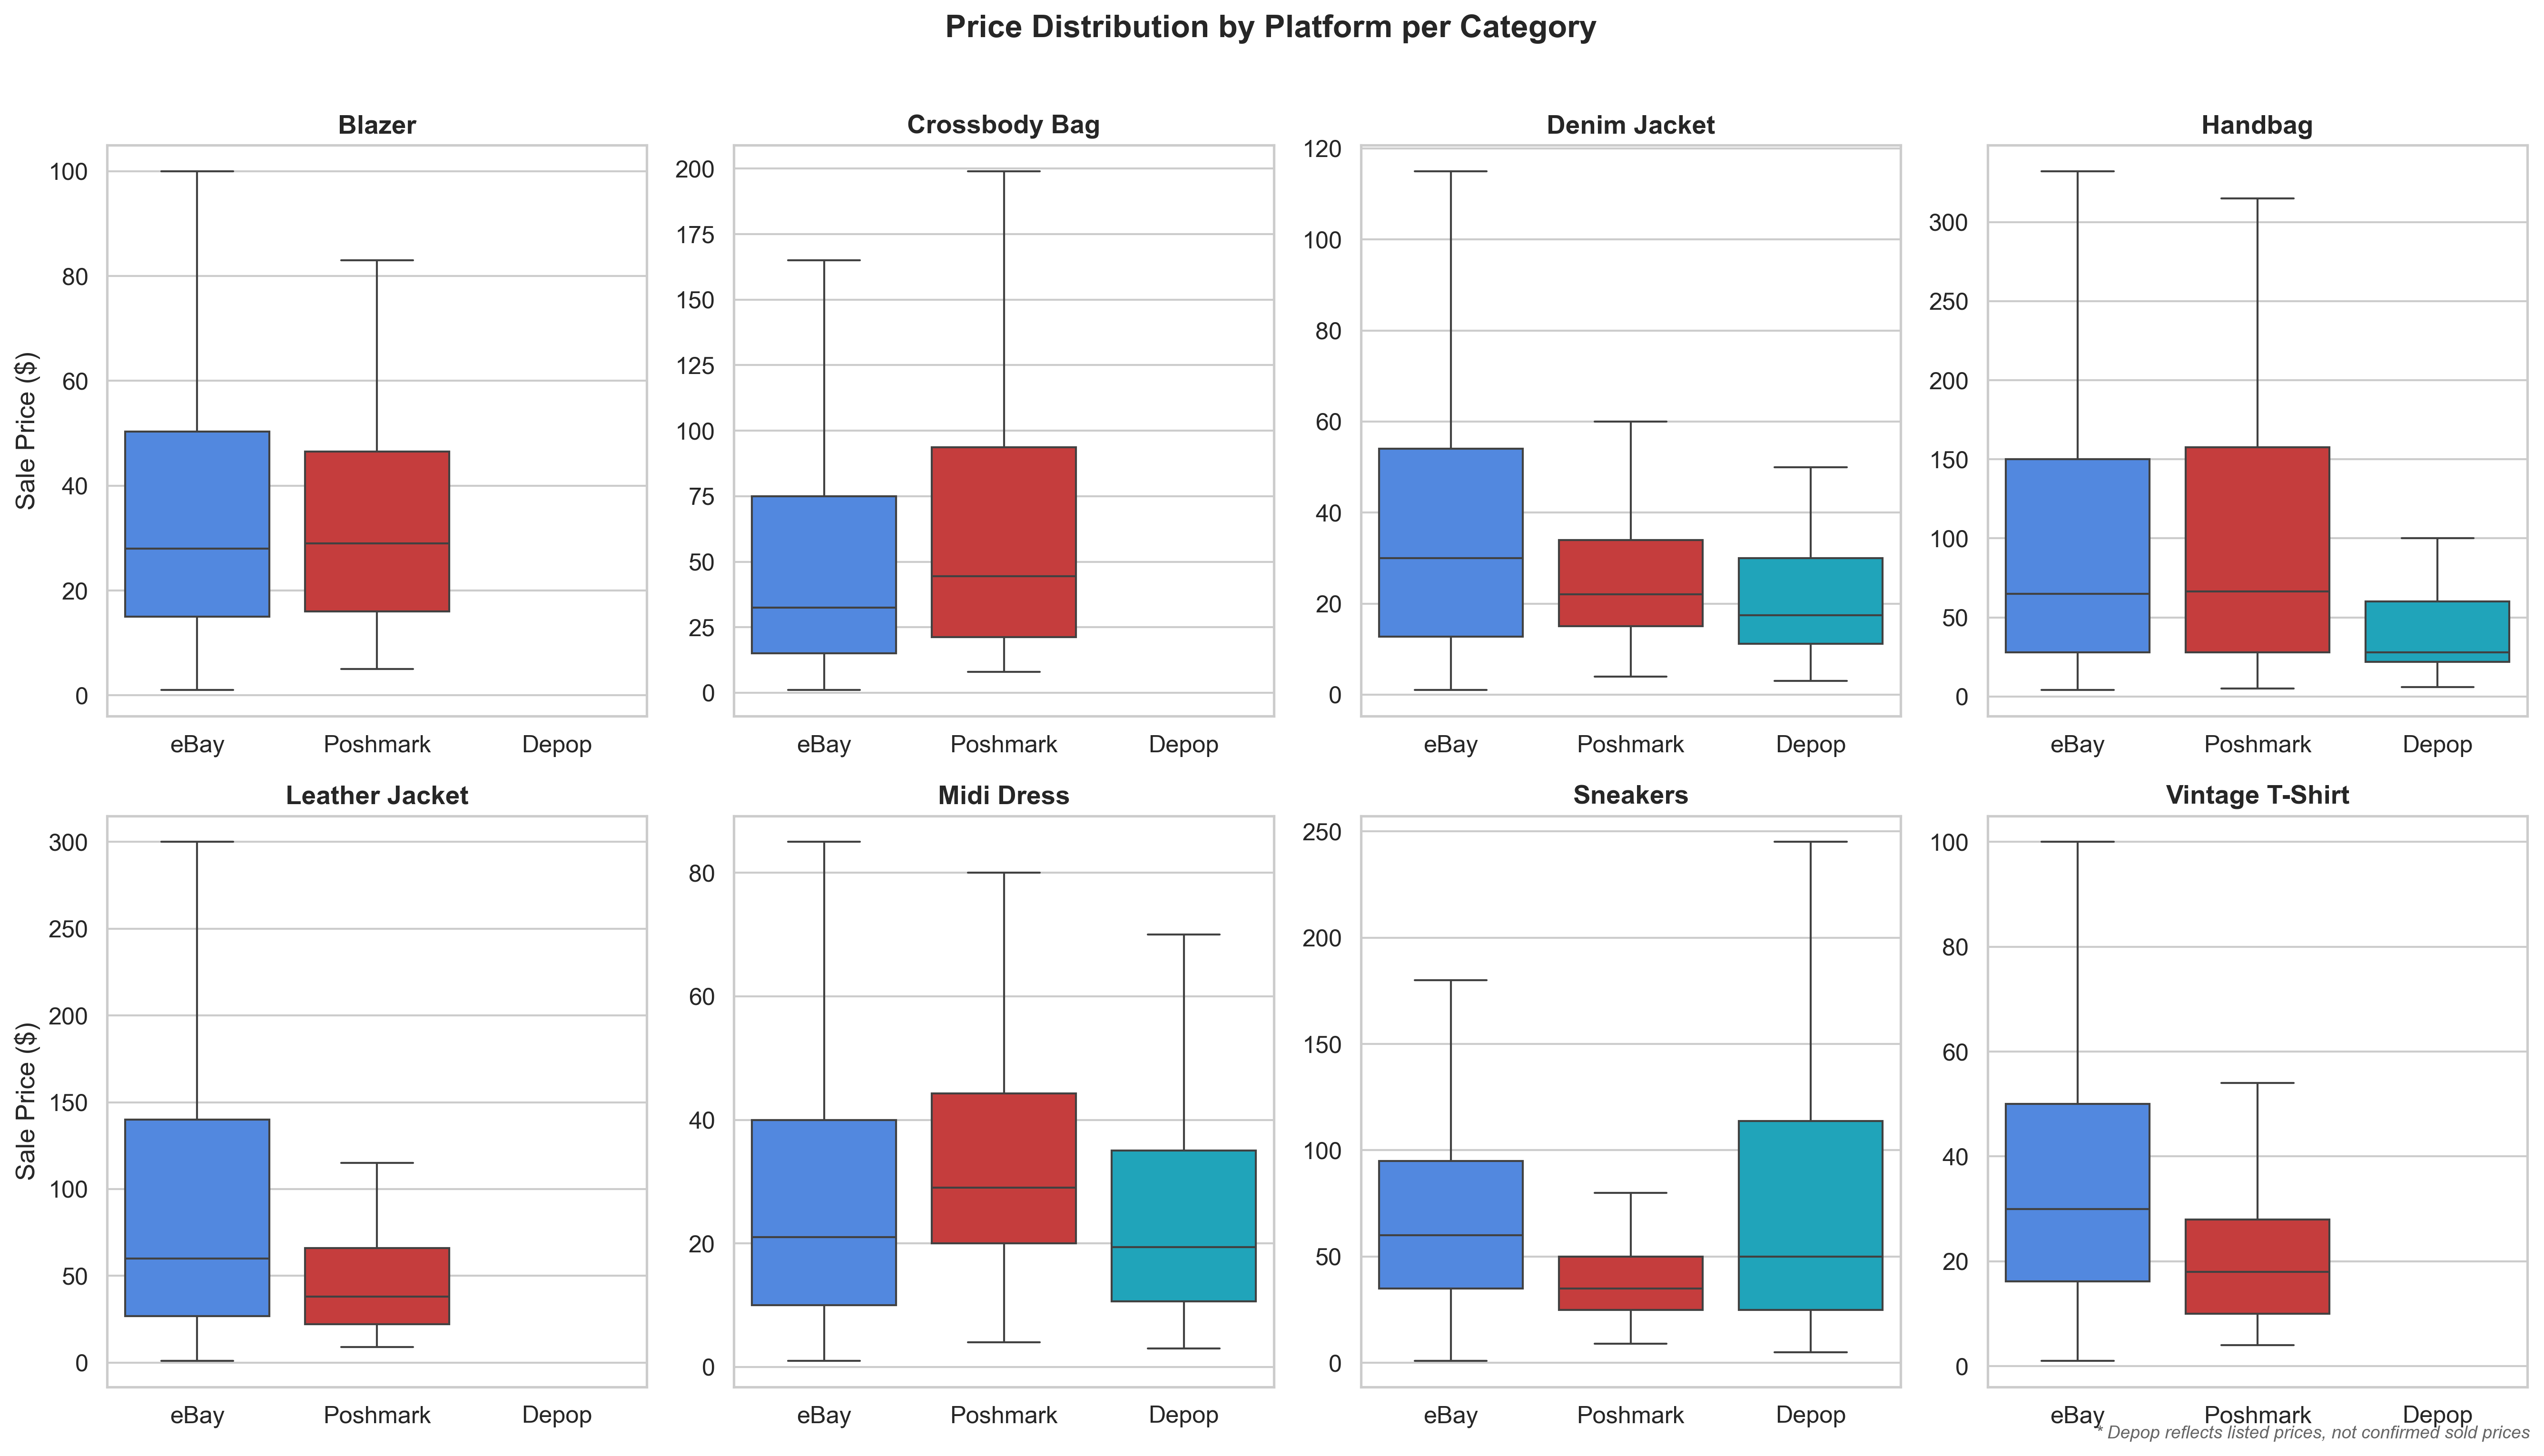

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=False)
axes = axes.flatten()

palette = [PLATFORM_COLORS[p] for p in PLATFORM_ORDER]

for i, cat in enumerate(categories):
    cat_df = df[df["item_category"] == cat]
    sns.boxplot(data=cat_df, x="platform", y="final_sale_price", ax=axes[i],
                showfliers=False, order=PLATFORM_ORDER, palette=palette)
    axes[i].set_title(cat.title(), fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Sale Price ($)" if i % 4 == 0 else "")

fig.suptitle("Price Distribution by Platform per Category",
             fontsize=16, fontweight="bold", y=1.01)
add_depop_footnote(fig)
fig.tight_layout()
save_fig("price_by_platform_boxplots")

## Figure 2: Median Sale Price Heatmap

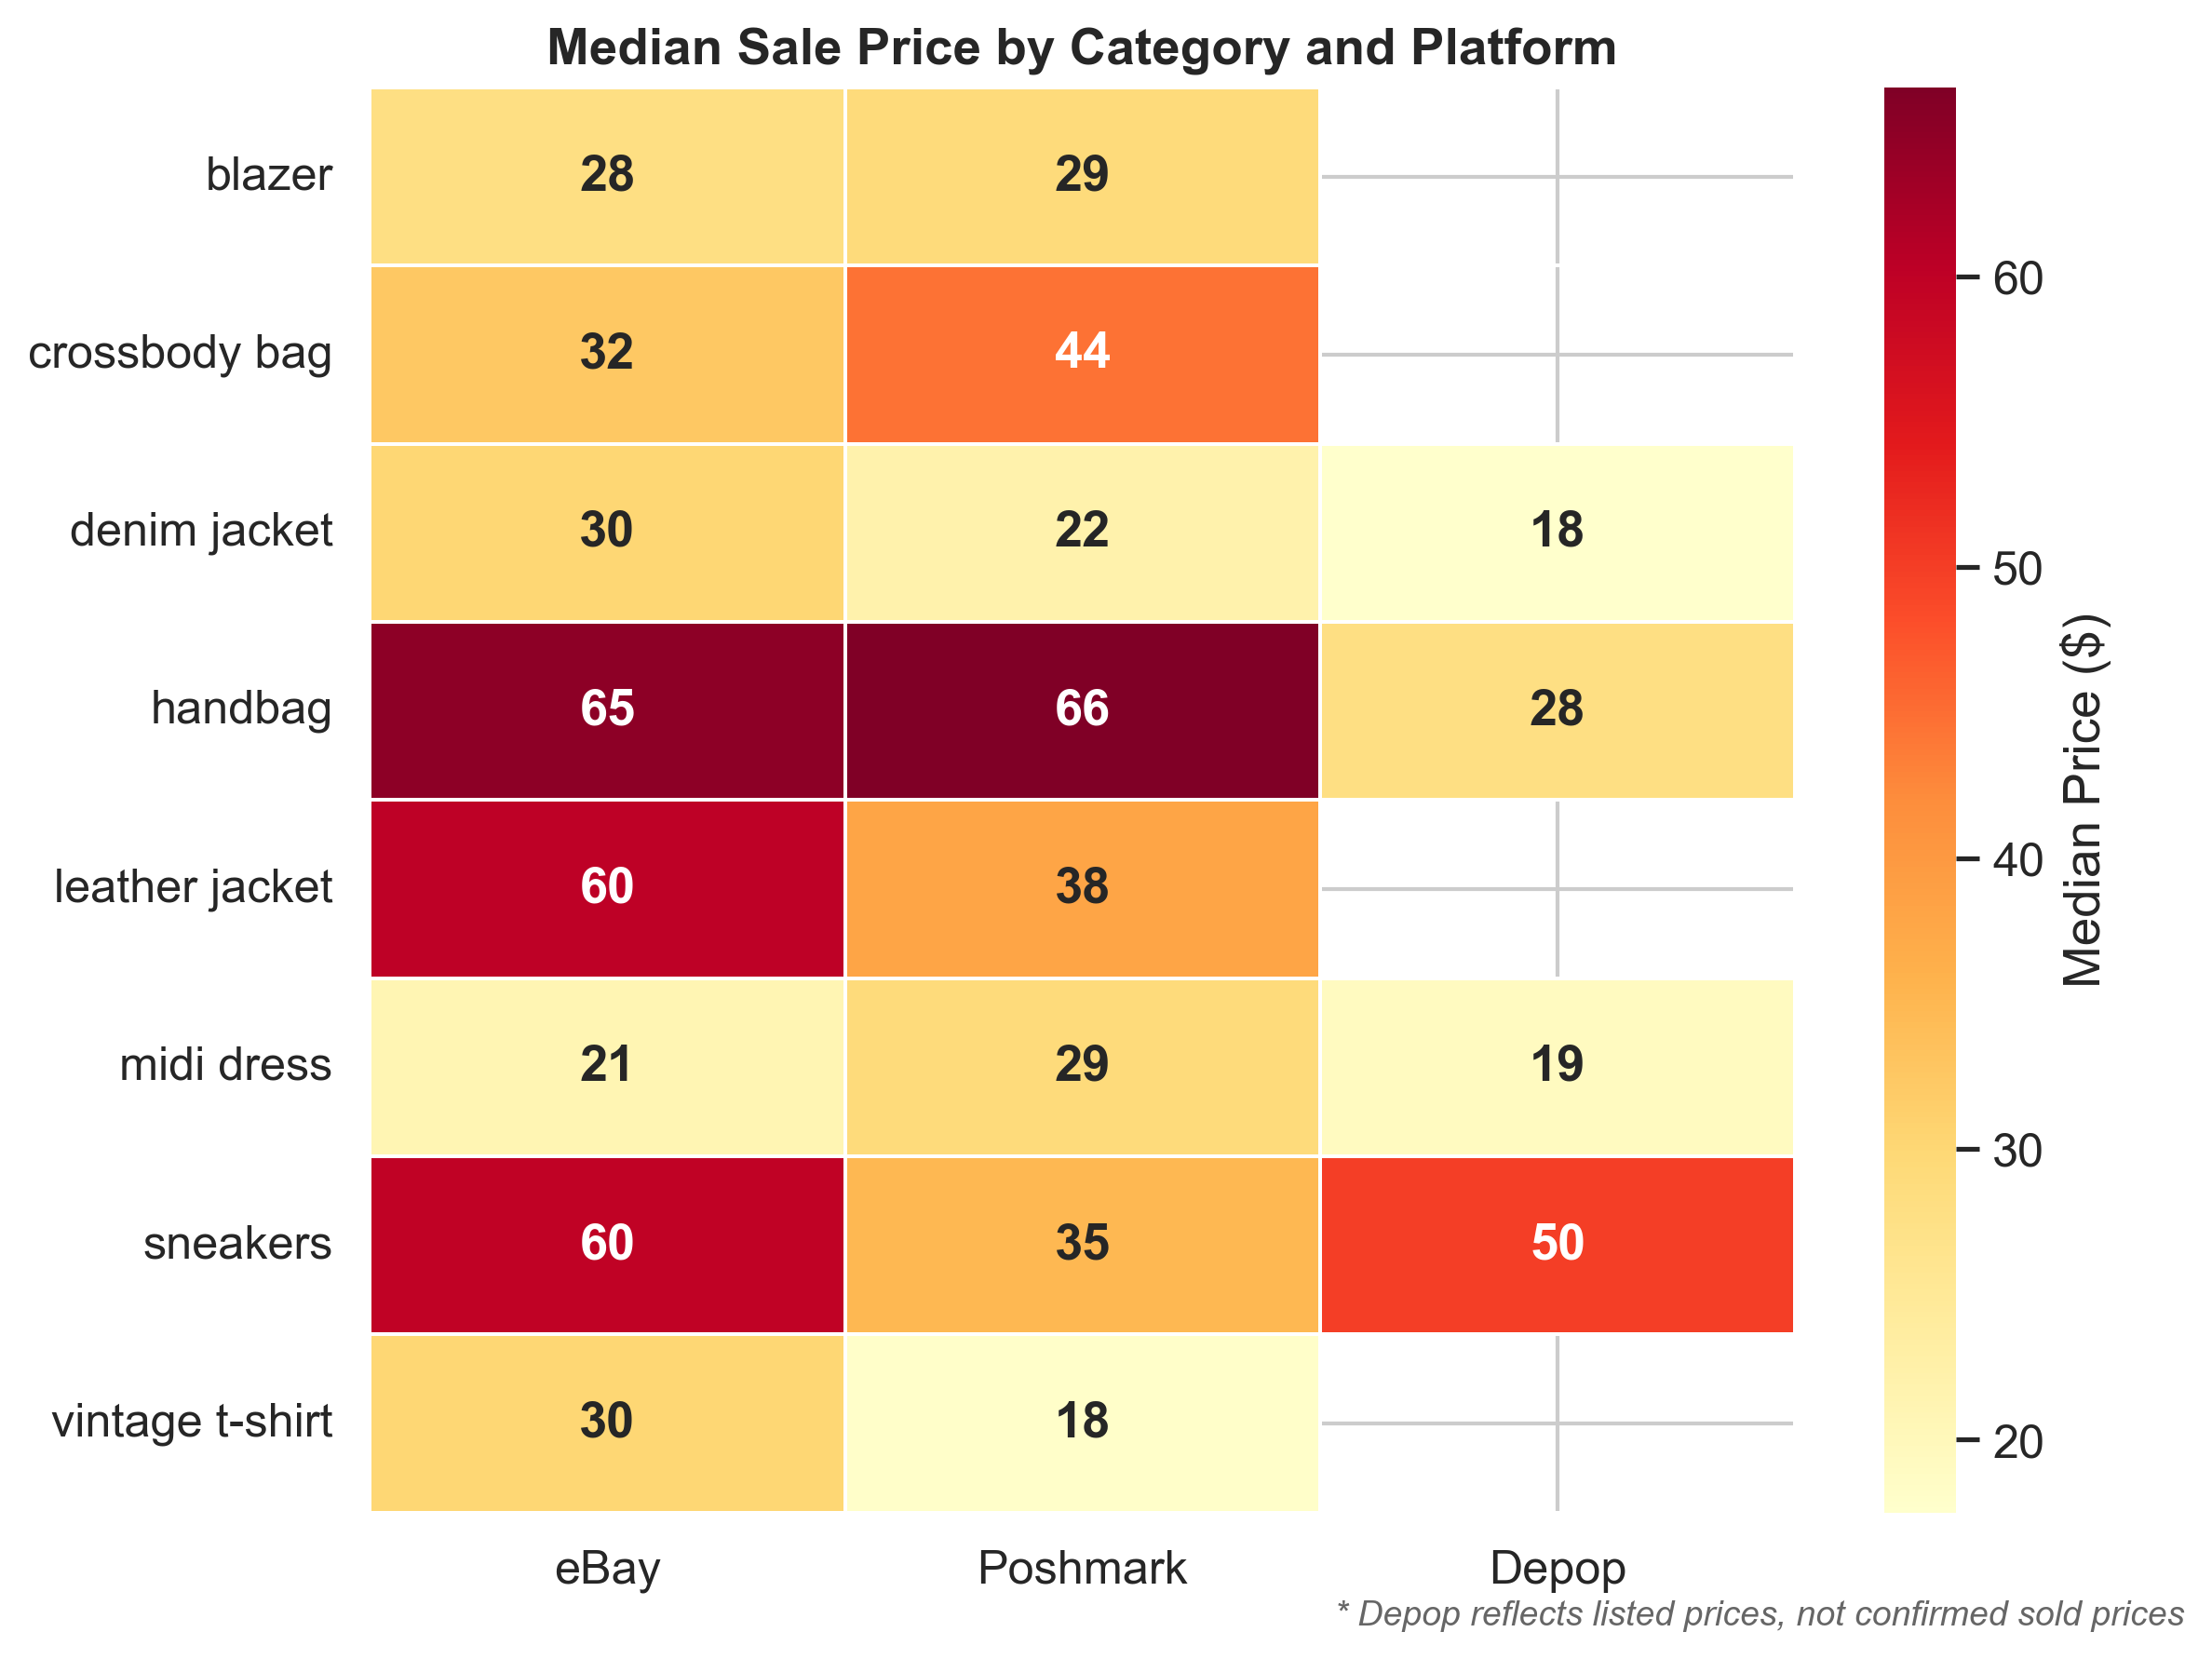

In [5]:
median_prices = df.pivot_table(values="final_sale_price", index="item_category",
                                columns="platform", aggfunc="median")
median_prices = median_prices.reindex(columns=PLATFORM_ORDER)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(median_prices, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Median Price ($)"},
            annot_kws={"fontsize": 13, "fontweight": "bold"})
ax.set_title("Median Sale Price by Category and Platform", fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
add_depop_footnote(fig)
fig.tight_layout()
save_fig("median_price_heatmap")

## Figure 3: Effective Hourly Rate Distribution

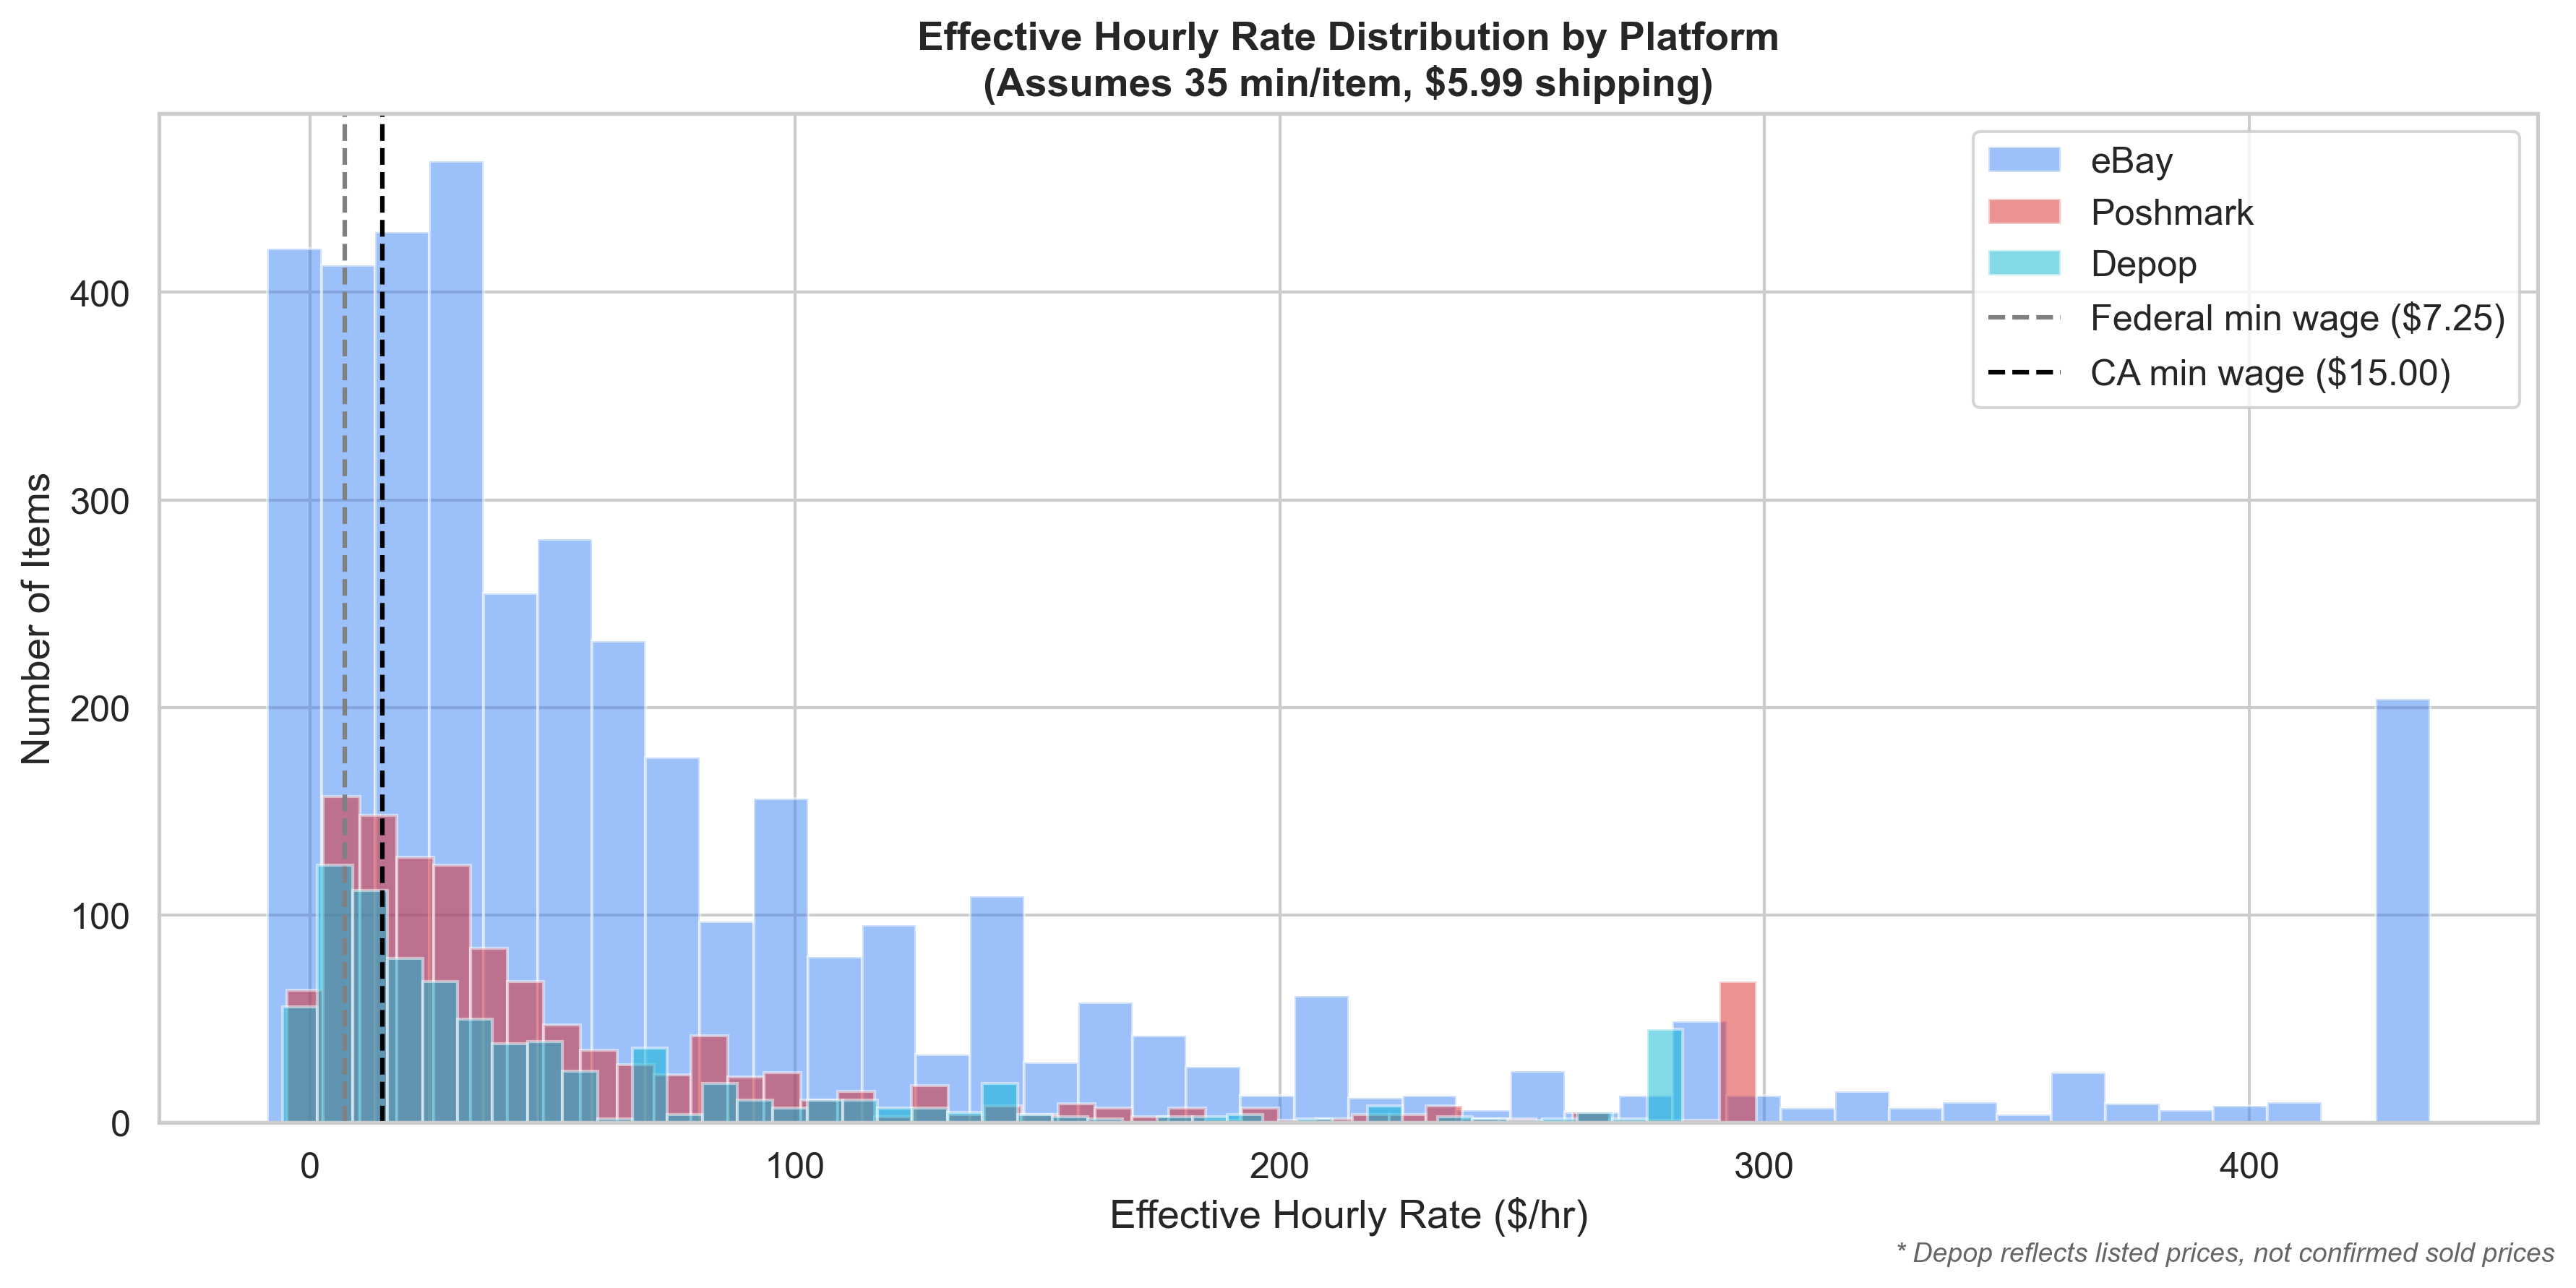

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for plat in PLATFORM_ORDER:
    plat_data = df.loc[df["platform"] == plat, "effective_hourly_rate"]
    plat_data = plat_data.clip(upper=plat_data.quantile(0.95))
    ax.hist(plat_data, bins=40, alpha=0.5, label=plat,
            color=PLATFORM_COLORS[plat], edgecolor="white")

ax.axvline(7.25, color="gray", linestyle="--", linewidth=1.5, label="Federal min wage ($7.25)")
ax.axvline(15.00, color="black", linestyle="--", linewidth=1.5, label="CA min wage ($15.00)")
ax.set_xlabel("Effective Hourly Rate ($/hr)")
ax.set_ylabel("Number of Items")
ax.set_title("Effective Hourly Rate Distribution by Platform\n(Assumes 35 min/item, $5.99 shipping)",
             fontweight="bold")
ax.legend()
add_depop_footnote(fig)
fig.tight_layout()
save_fig("hourly_rate_distribution")

## Figure 4: "Don't Sell" by Platform

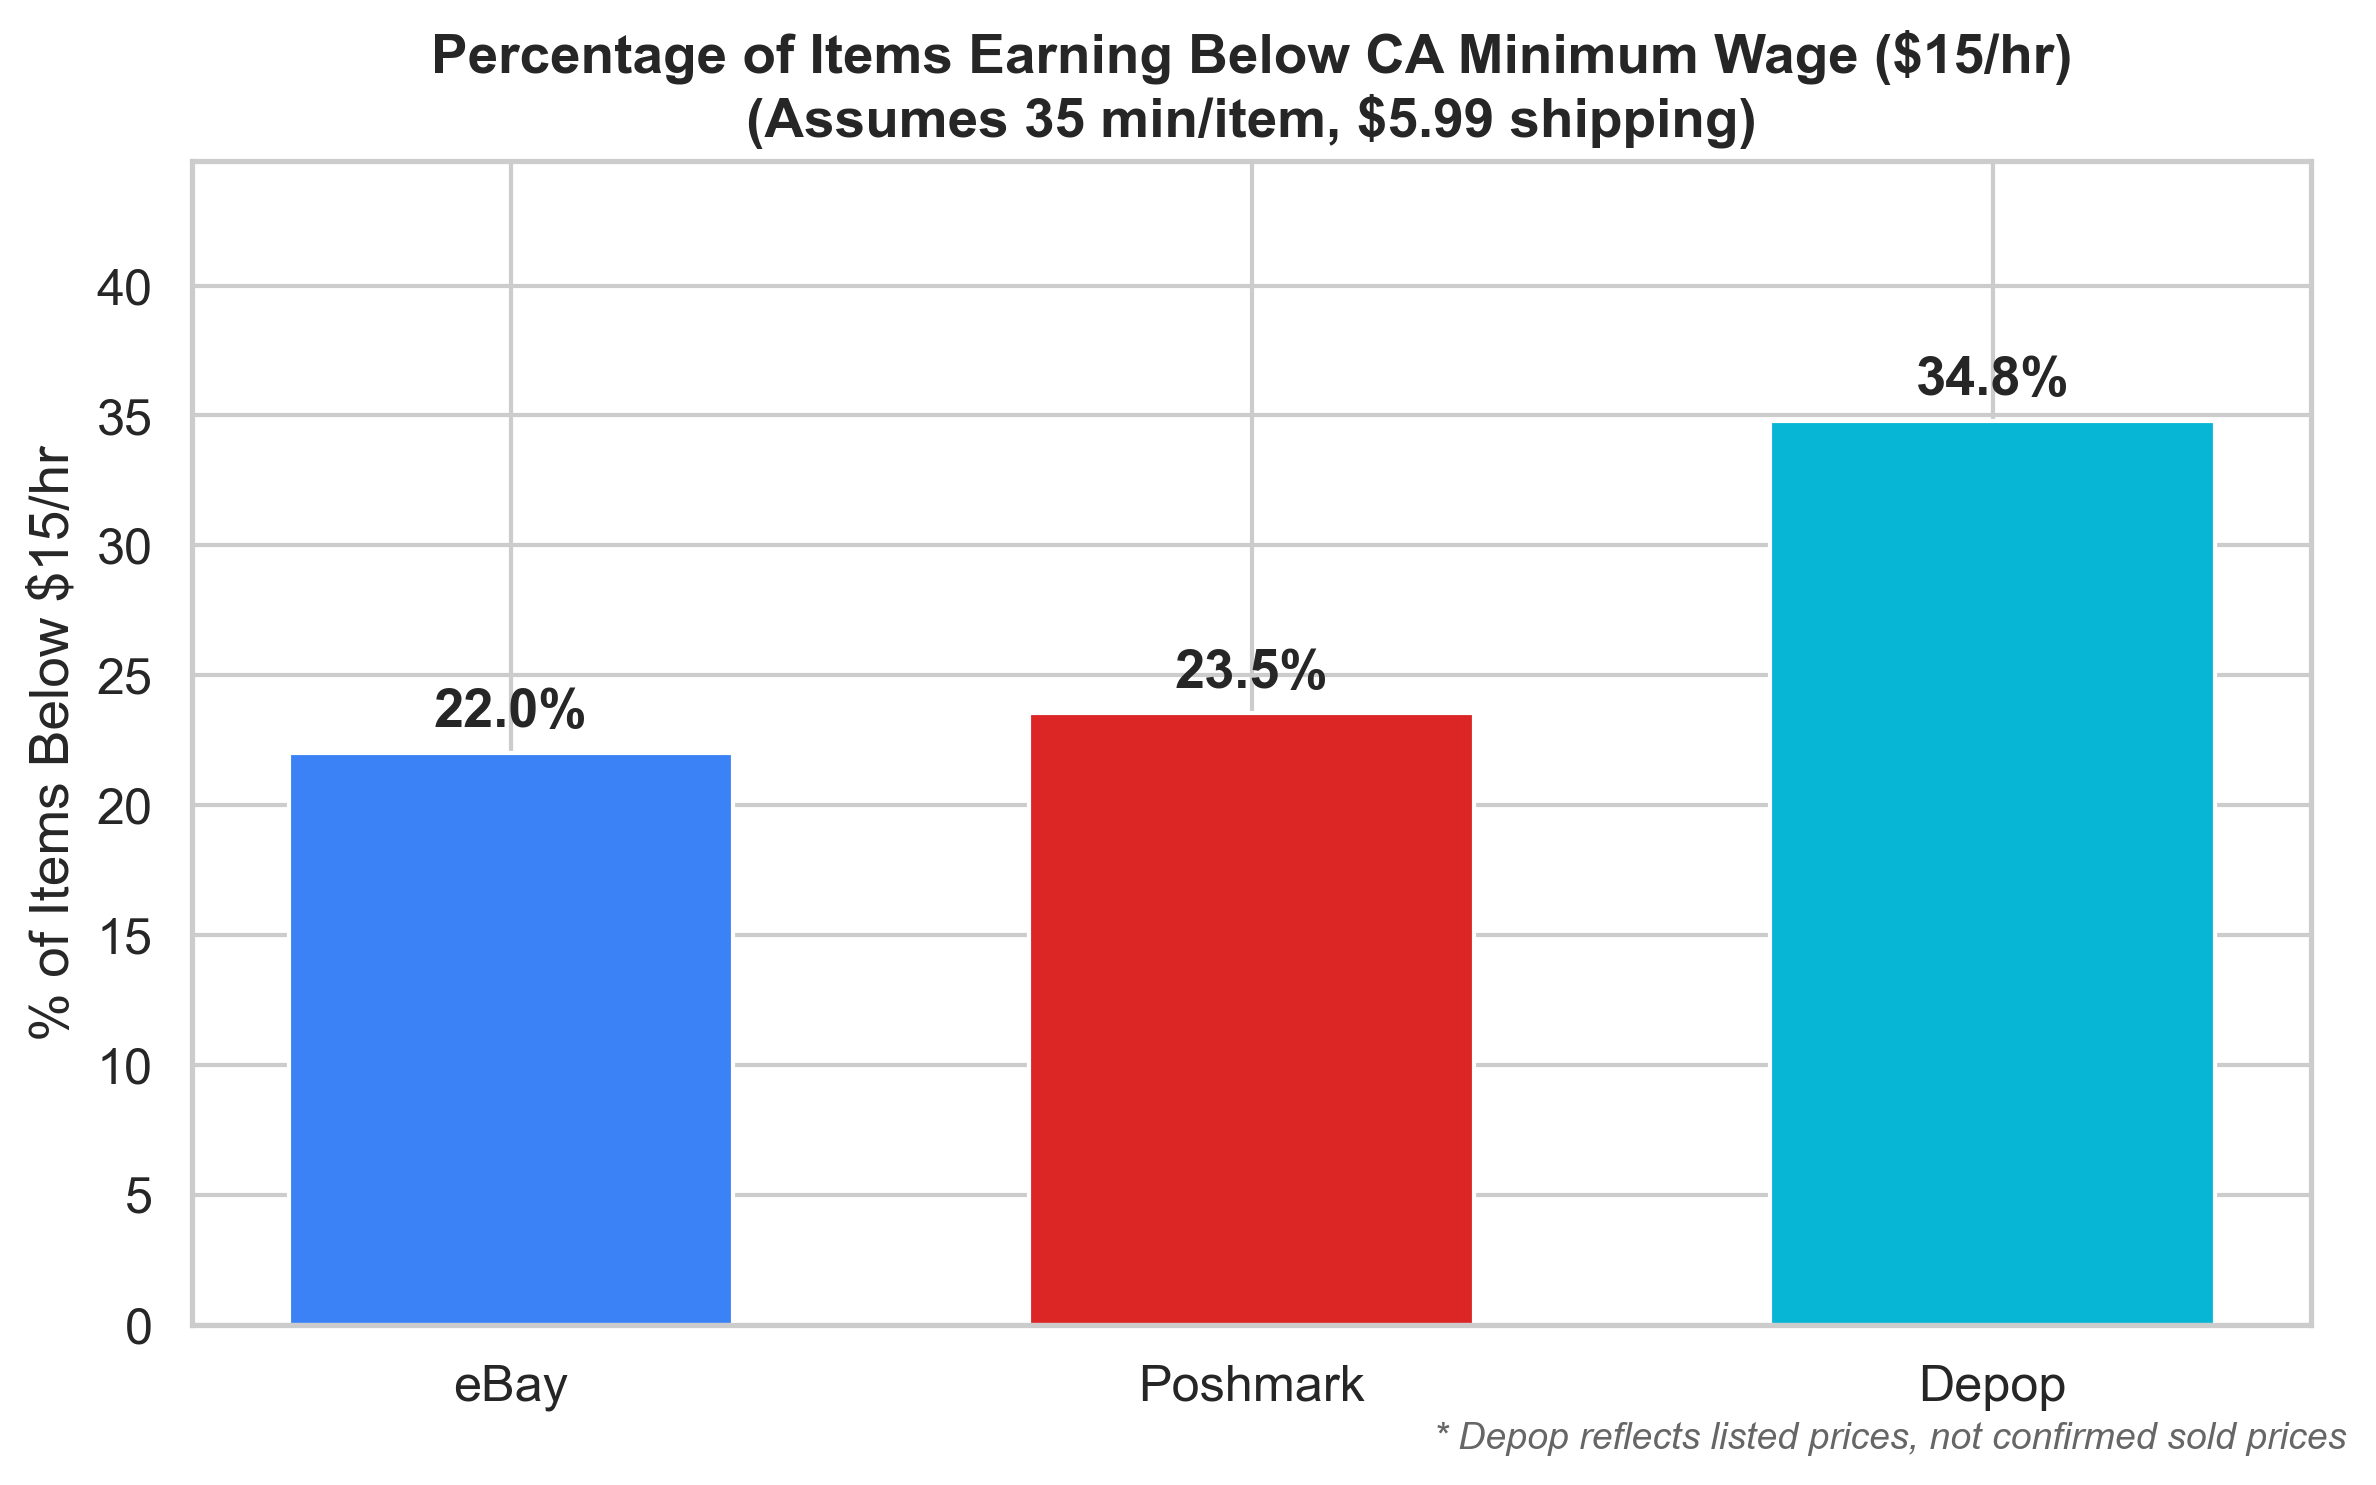

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

dont_sell_by_plat = df.groupby("platform")["dont_sell"].mean().mul(100).reindex(PLATFORM_ORDER)
bars = ax.bar(dont_sell_by_plat.index, dont_sell_by_plat.values,
              color=[PLATFORM_COLORS[p] for p in dont_sell_by_plat.index],
              edgecolor="white", width=0.6)

for bar, val in zip(bars, dont_sell_by_plat.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=13)

ax.set_ylabel("% of Items Below $15/hr")
ax.set_title("Percentage of Items Earning Below CA Minimum Wage ($15/hr)\n(Assumes 35 min/item, $5.99 shipping)",
             fontweight="bold")
ax.set_ylim(0, max(dont_sell_by_plat.values) + 10)
add_depop_footnote(fig)
fig.tight_layout()
save_fig("dont_sell_by_platform")

## Figure 5: Best Platform Heatmap (Net Profit)

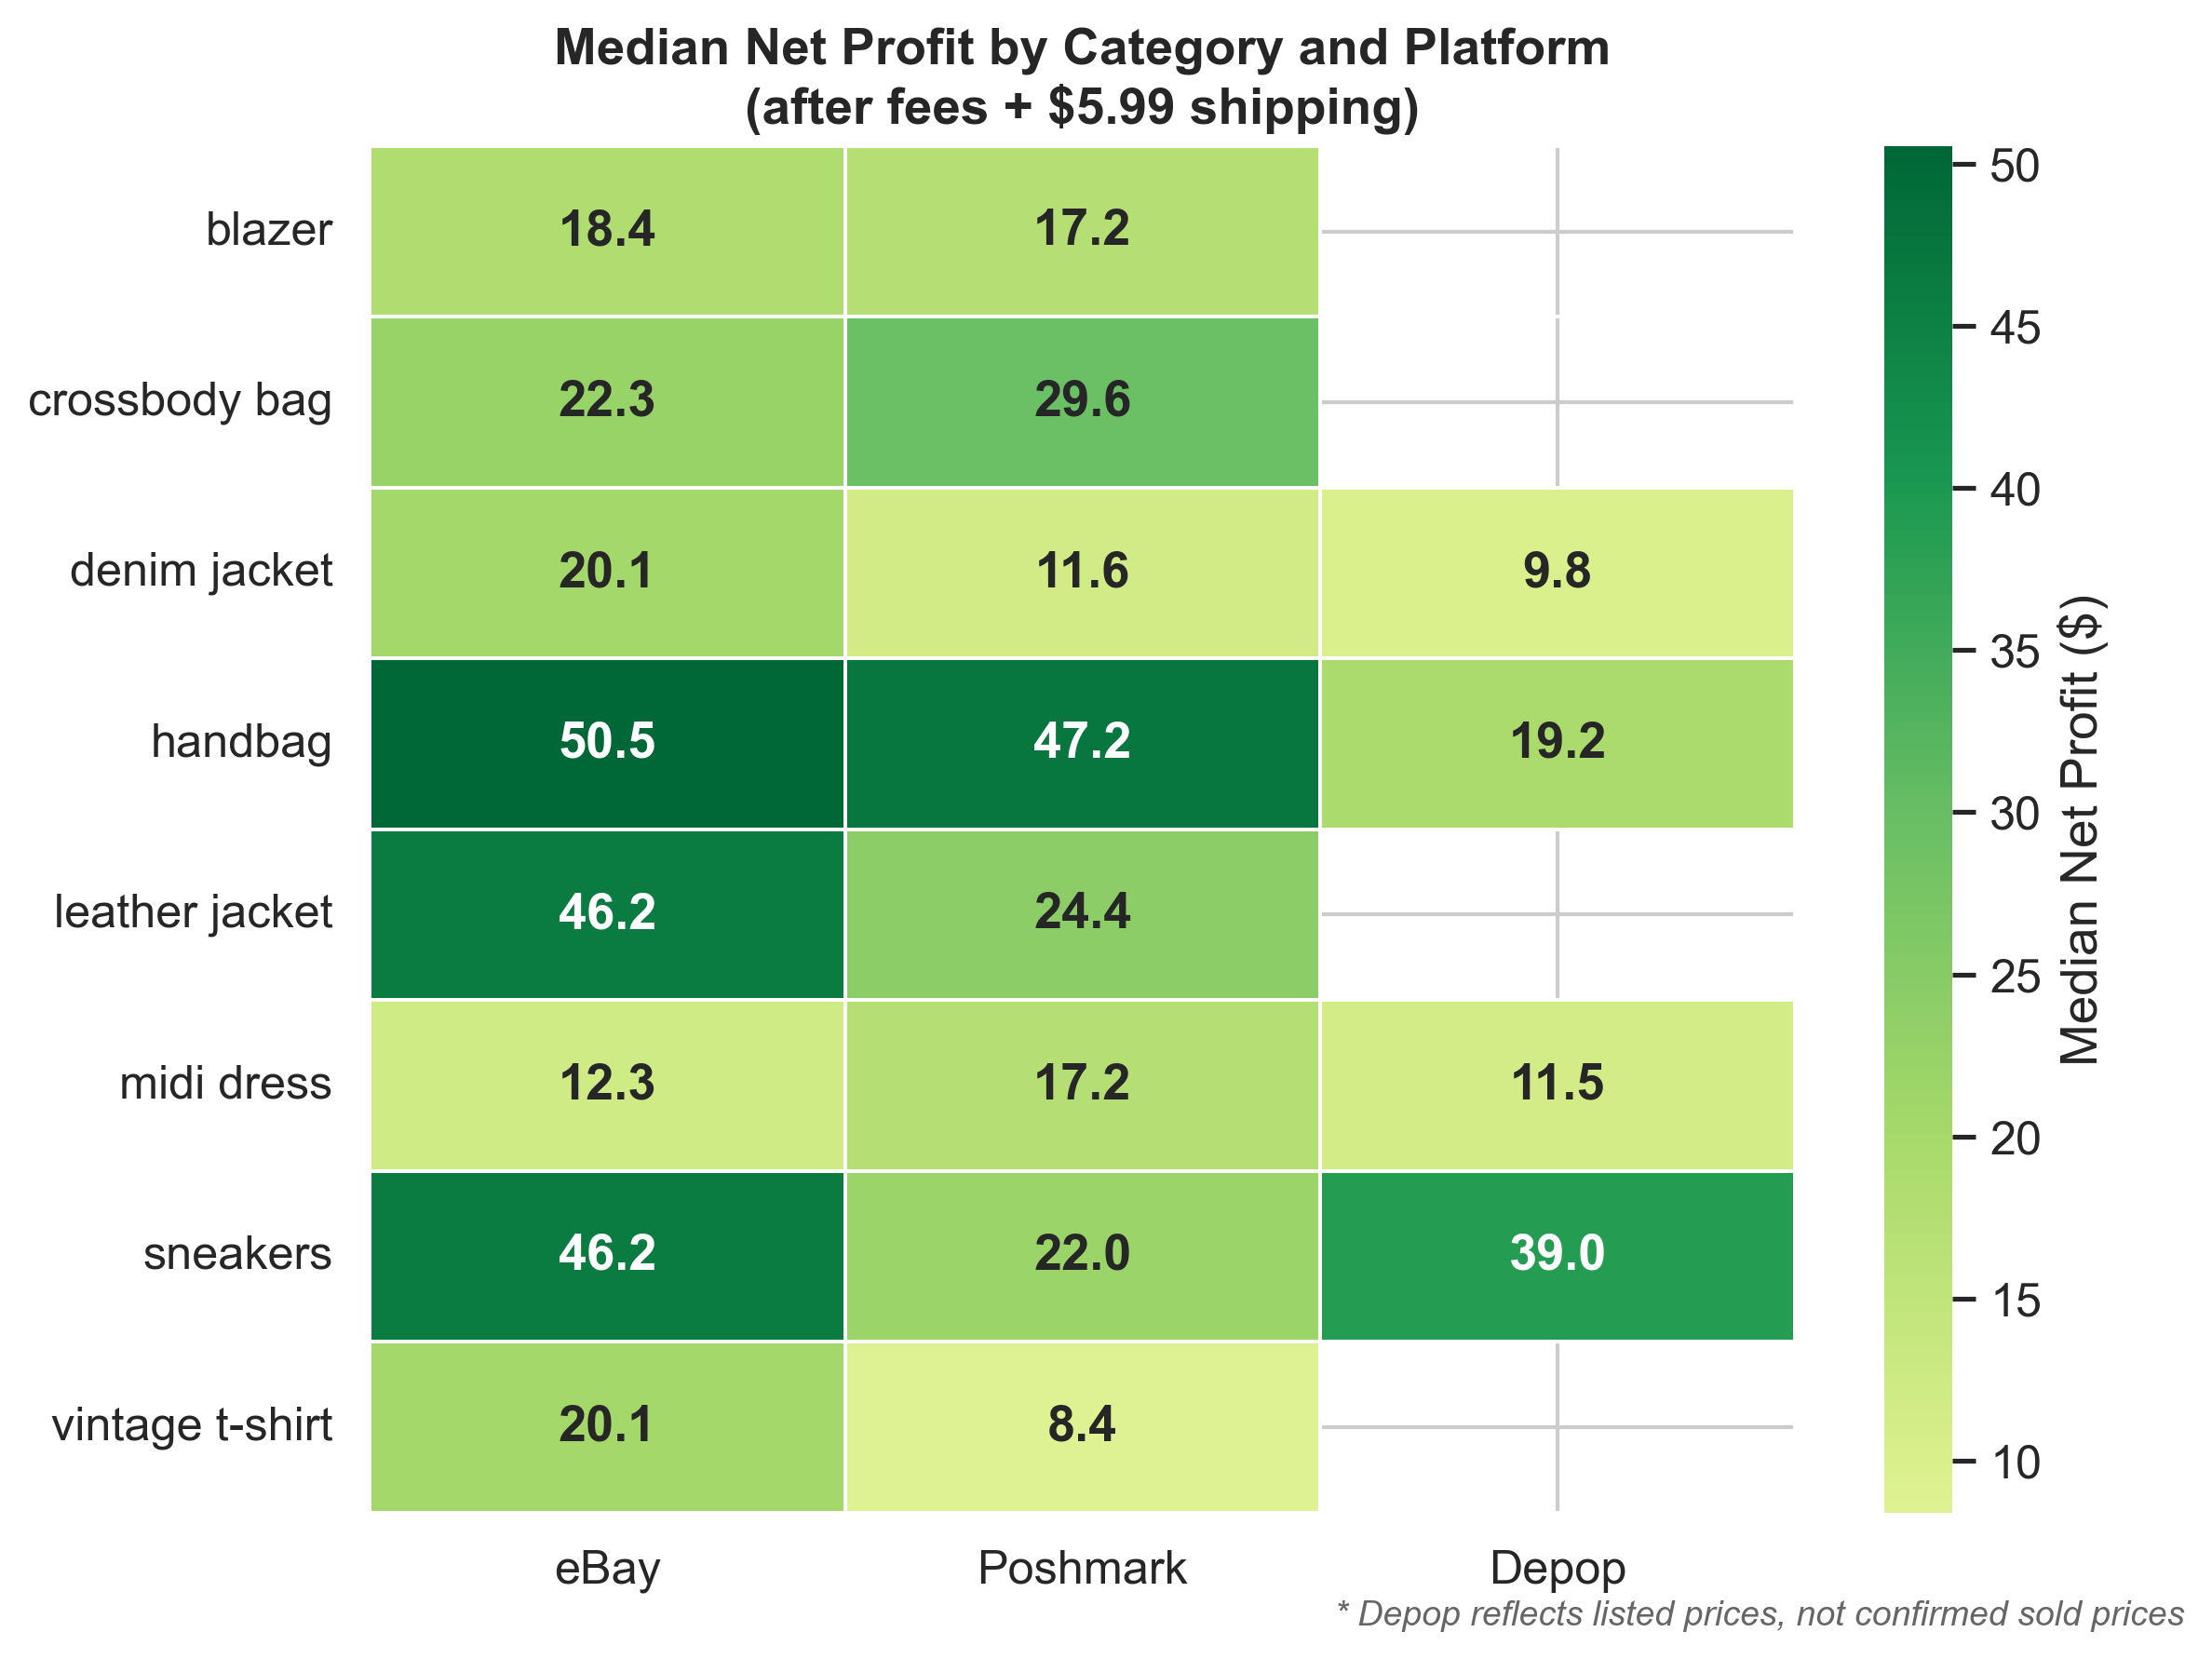

In [8]:
net_profit_pivot = df.pivot_table(values="net_profit", index="item_category",
                                   columns="platform", aggfunc="median")
net_profit_pivot = net_profit_pivot.reindex(columns=PLATFORM_ORDER)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(net_profit_pivot, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax,
            linewidths=0.5, center=0, cbar_kws={"label": "Median Net Profit ($)"},
            annot_kws={"fontsize": 13, "fontweight": "bold"})
ax.set_title("Median Net Profit by Category and Platform\n(after fees + $5.99 shipping)",
             fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
add_depop_footnote(fig)
fig.tight_layout()
save_fig("best_platform_heatmap")

## Figure 6: Poshmark Sell Velocity

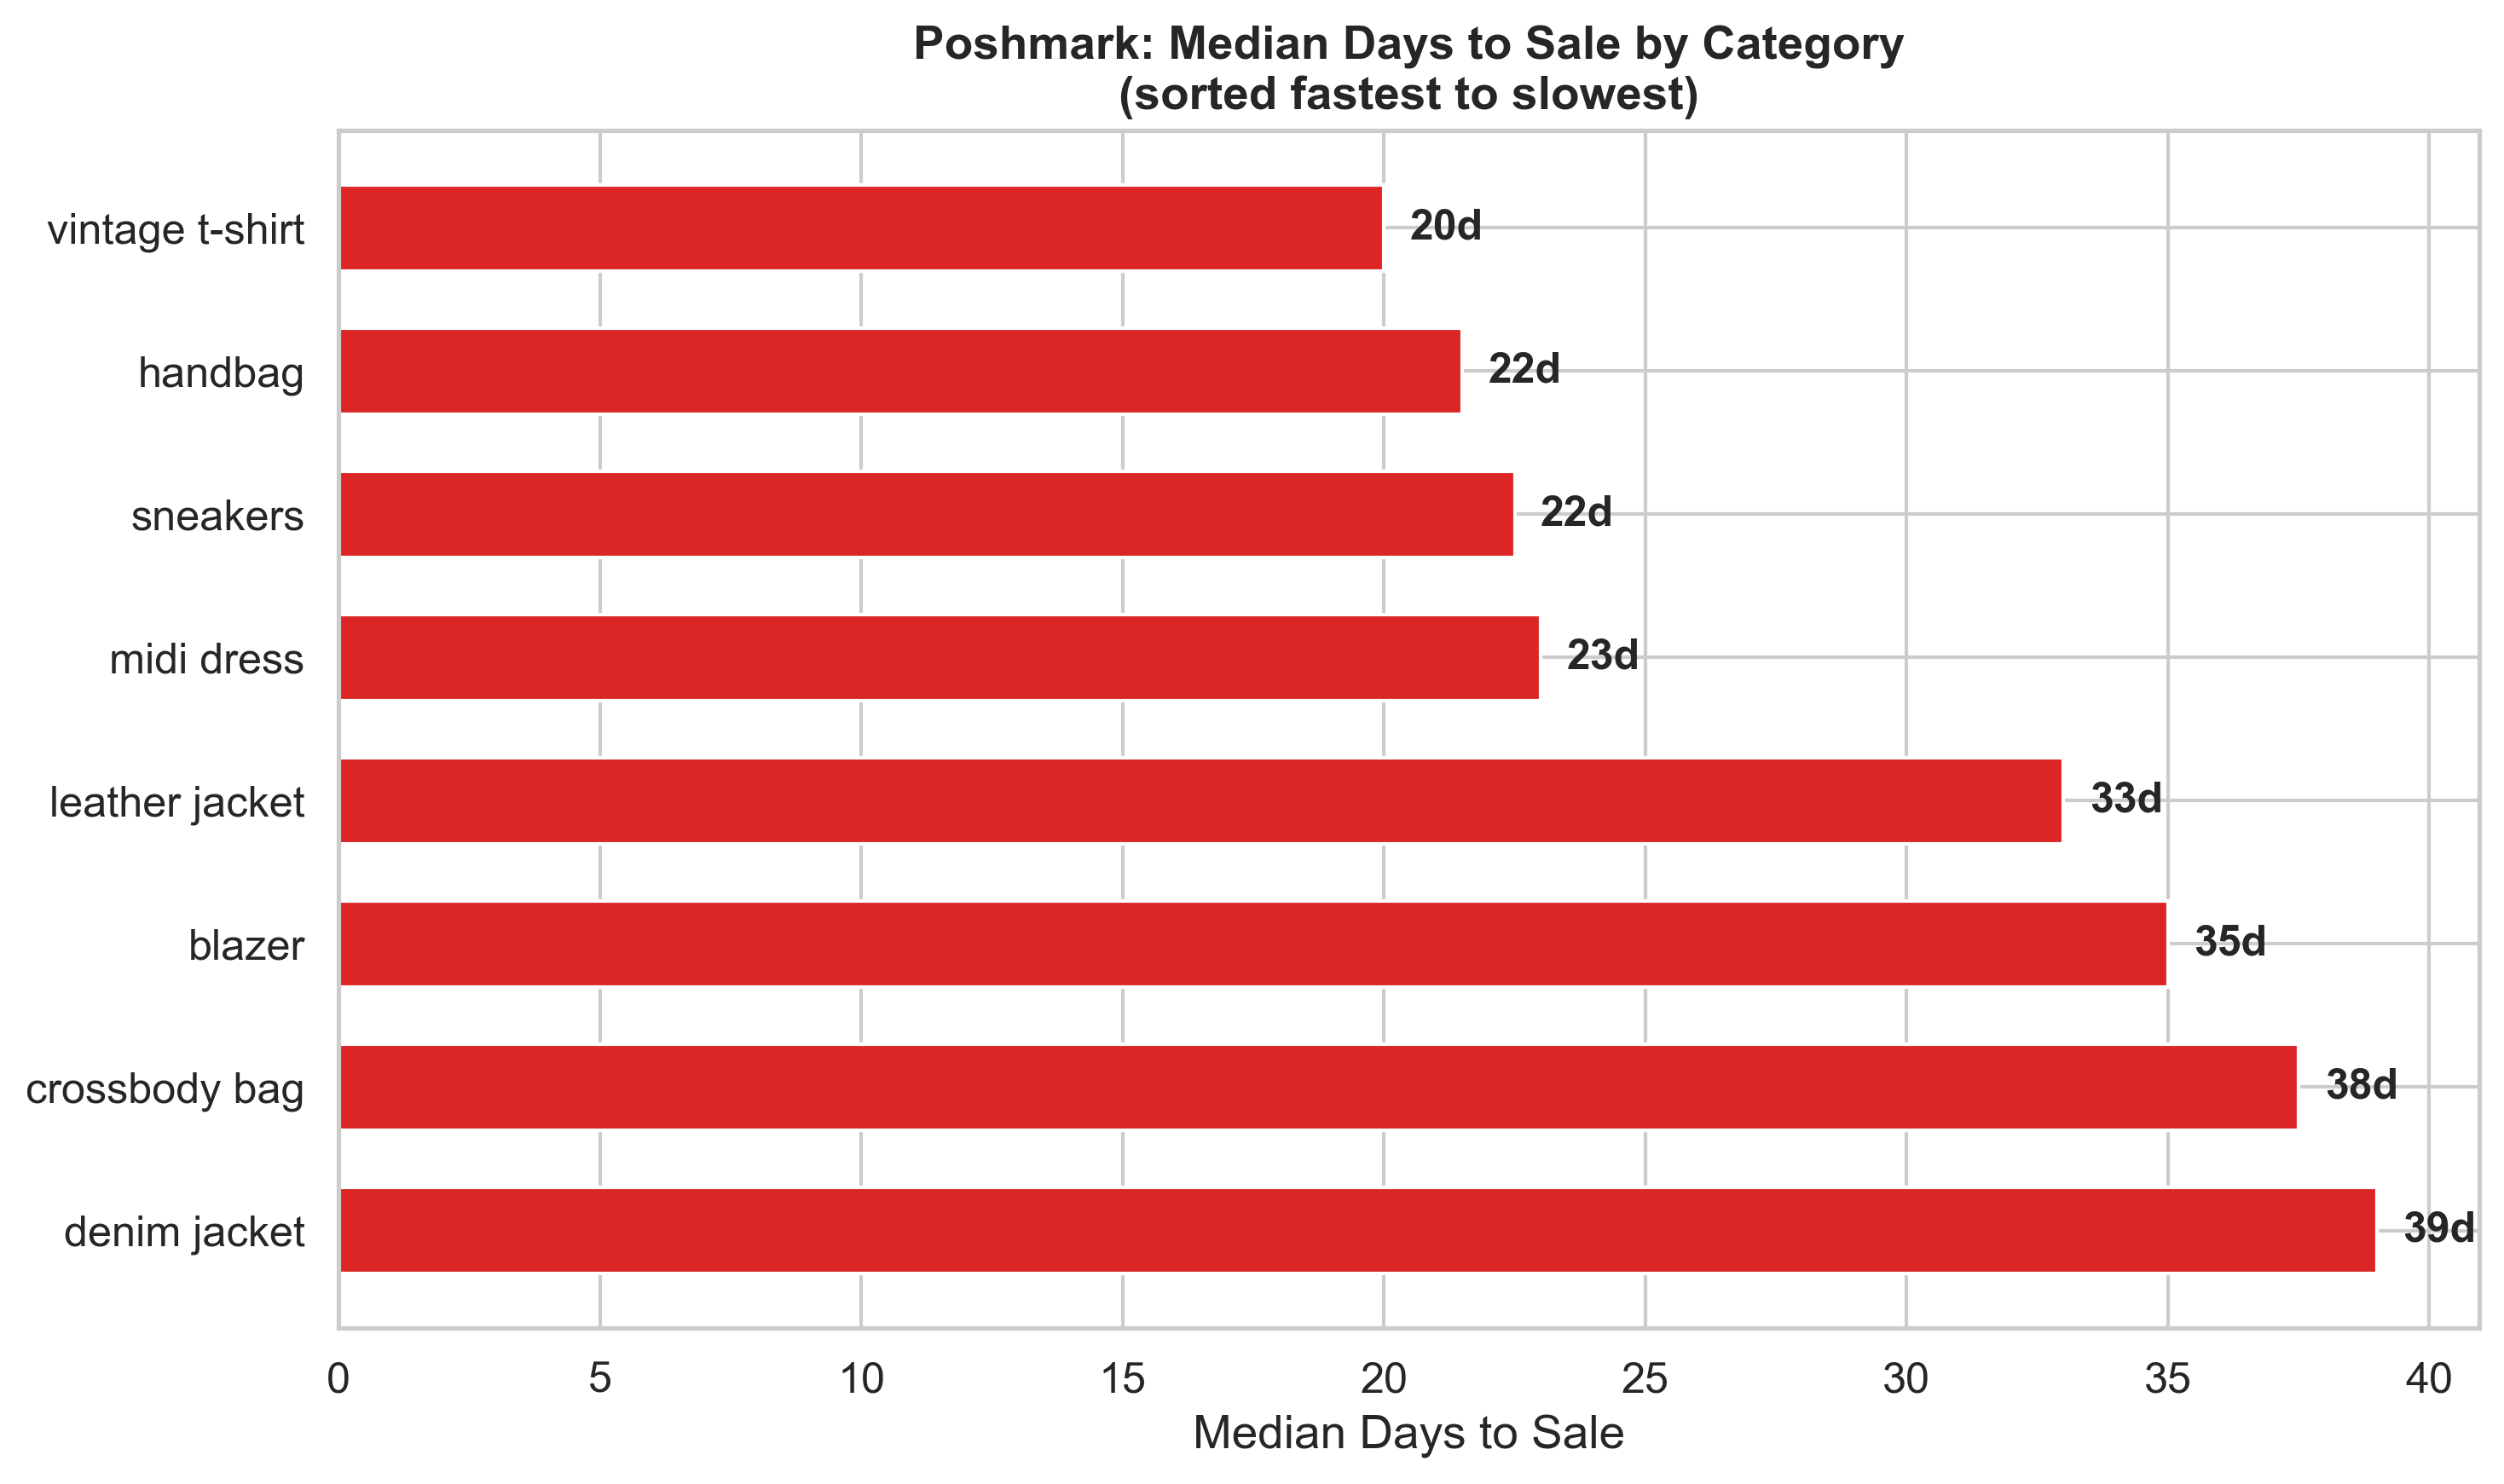

In [9]:
posh = df[df["platform"] == "Poshmark"].dropna(subset=["days_to_sale"])
velocity = posh.groupby("item_category")["days_to_sale"].agg(["median", "mean", "count"])
velocity.columns = ["median_days", "mean_days", "n_items"]
velocity = velocity.sort_values("median_days")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(velocity.index, velocity["median_days"],
               color=PLATFORM_COLORS["Poshmark"], edgecolor="white", height=0.6)

for bar, val in zip(bars, velocity["median_days"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}d", va="center", fontweight="bold", fontsize=12)

ax.set_xlabel("Median Days to Sale")
ax.set_title("Poshmark: Median Days to Sale by Category\n(sorted fastest to slowest)",
             fontweight="bold")
ax.invert_yaxis()
fig.tight_layout()
save_fig("poshmark_velocity_by_category")

## Figure 7: Feature Importance (Top 20)

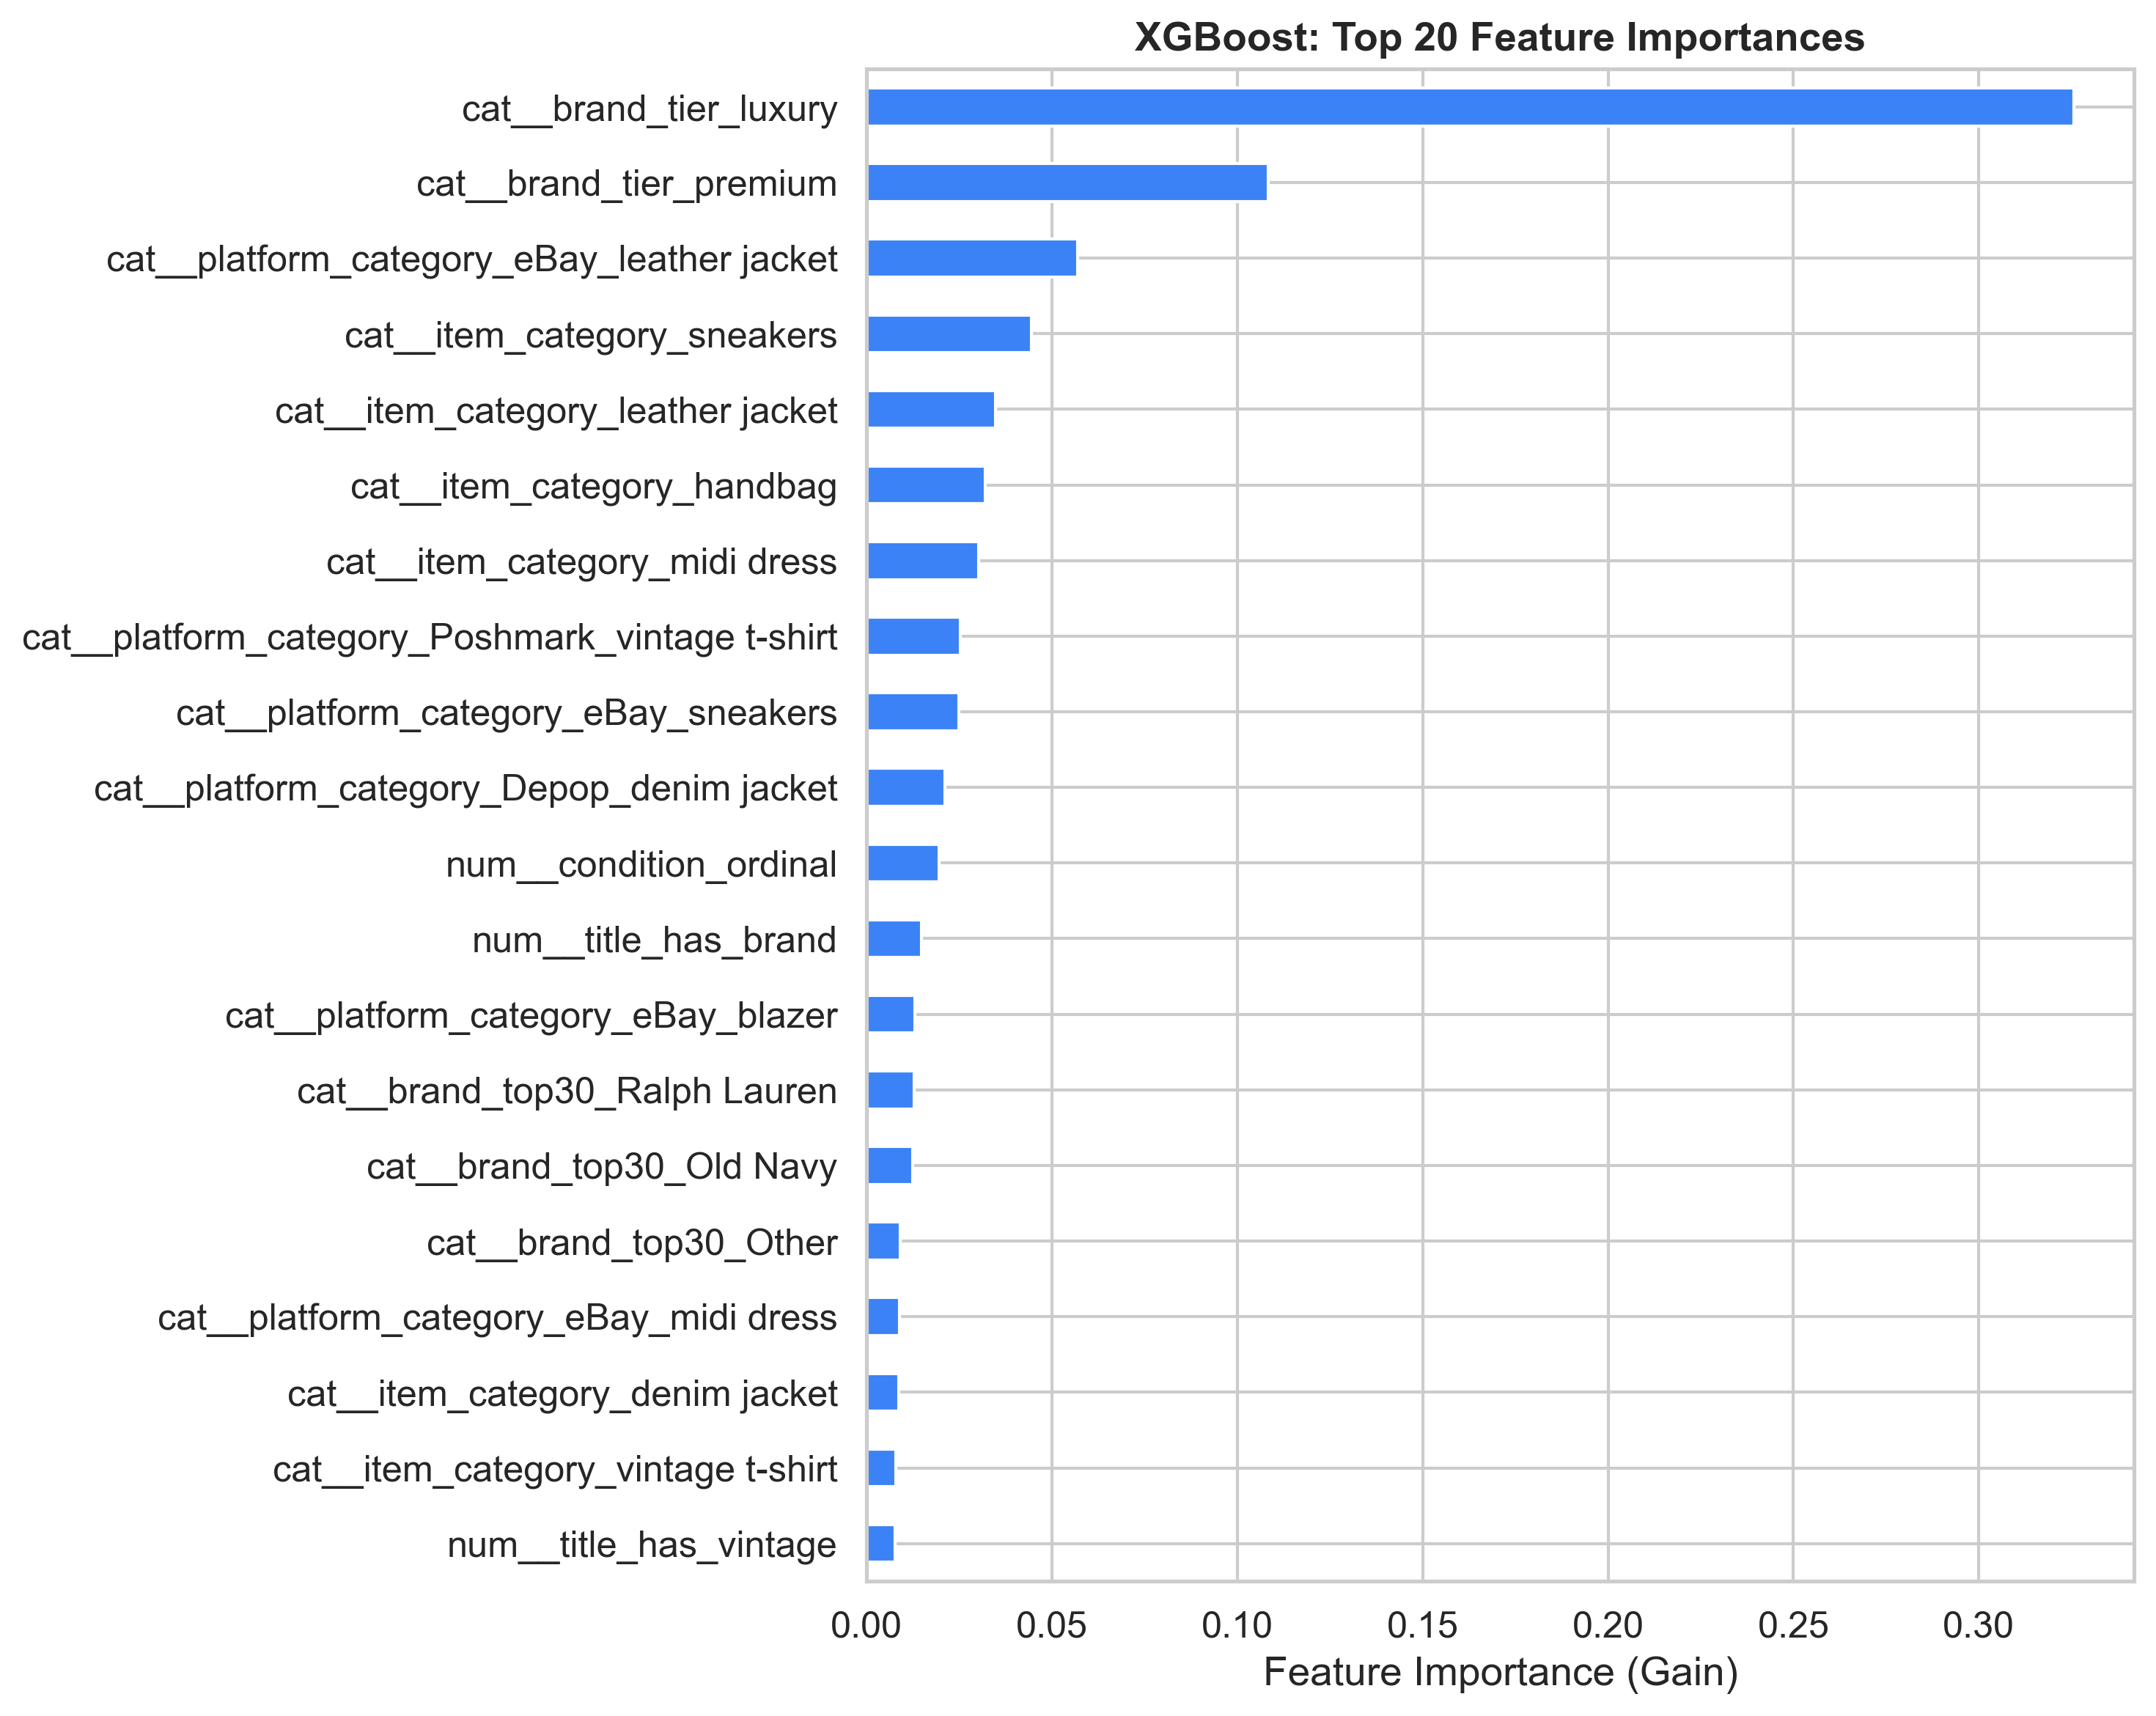

In [10]:
importances = pd.Series(xgb_model.feature_importances_, index=all_feature_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot.barh(ax=ax, color=PLATFORM_COLORS["eBay"], edgecolor="white")
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("XGBoost: Top 20 Feature Importances", fontweight="bold")
fig.tight_layout()
save_fig("feature_importance")

## Figure 8: Predicted vs Actual Price

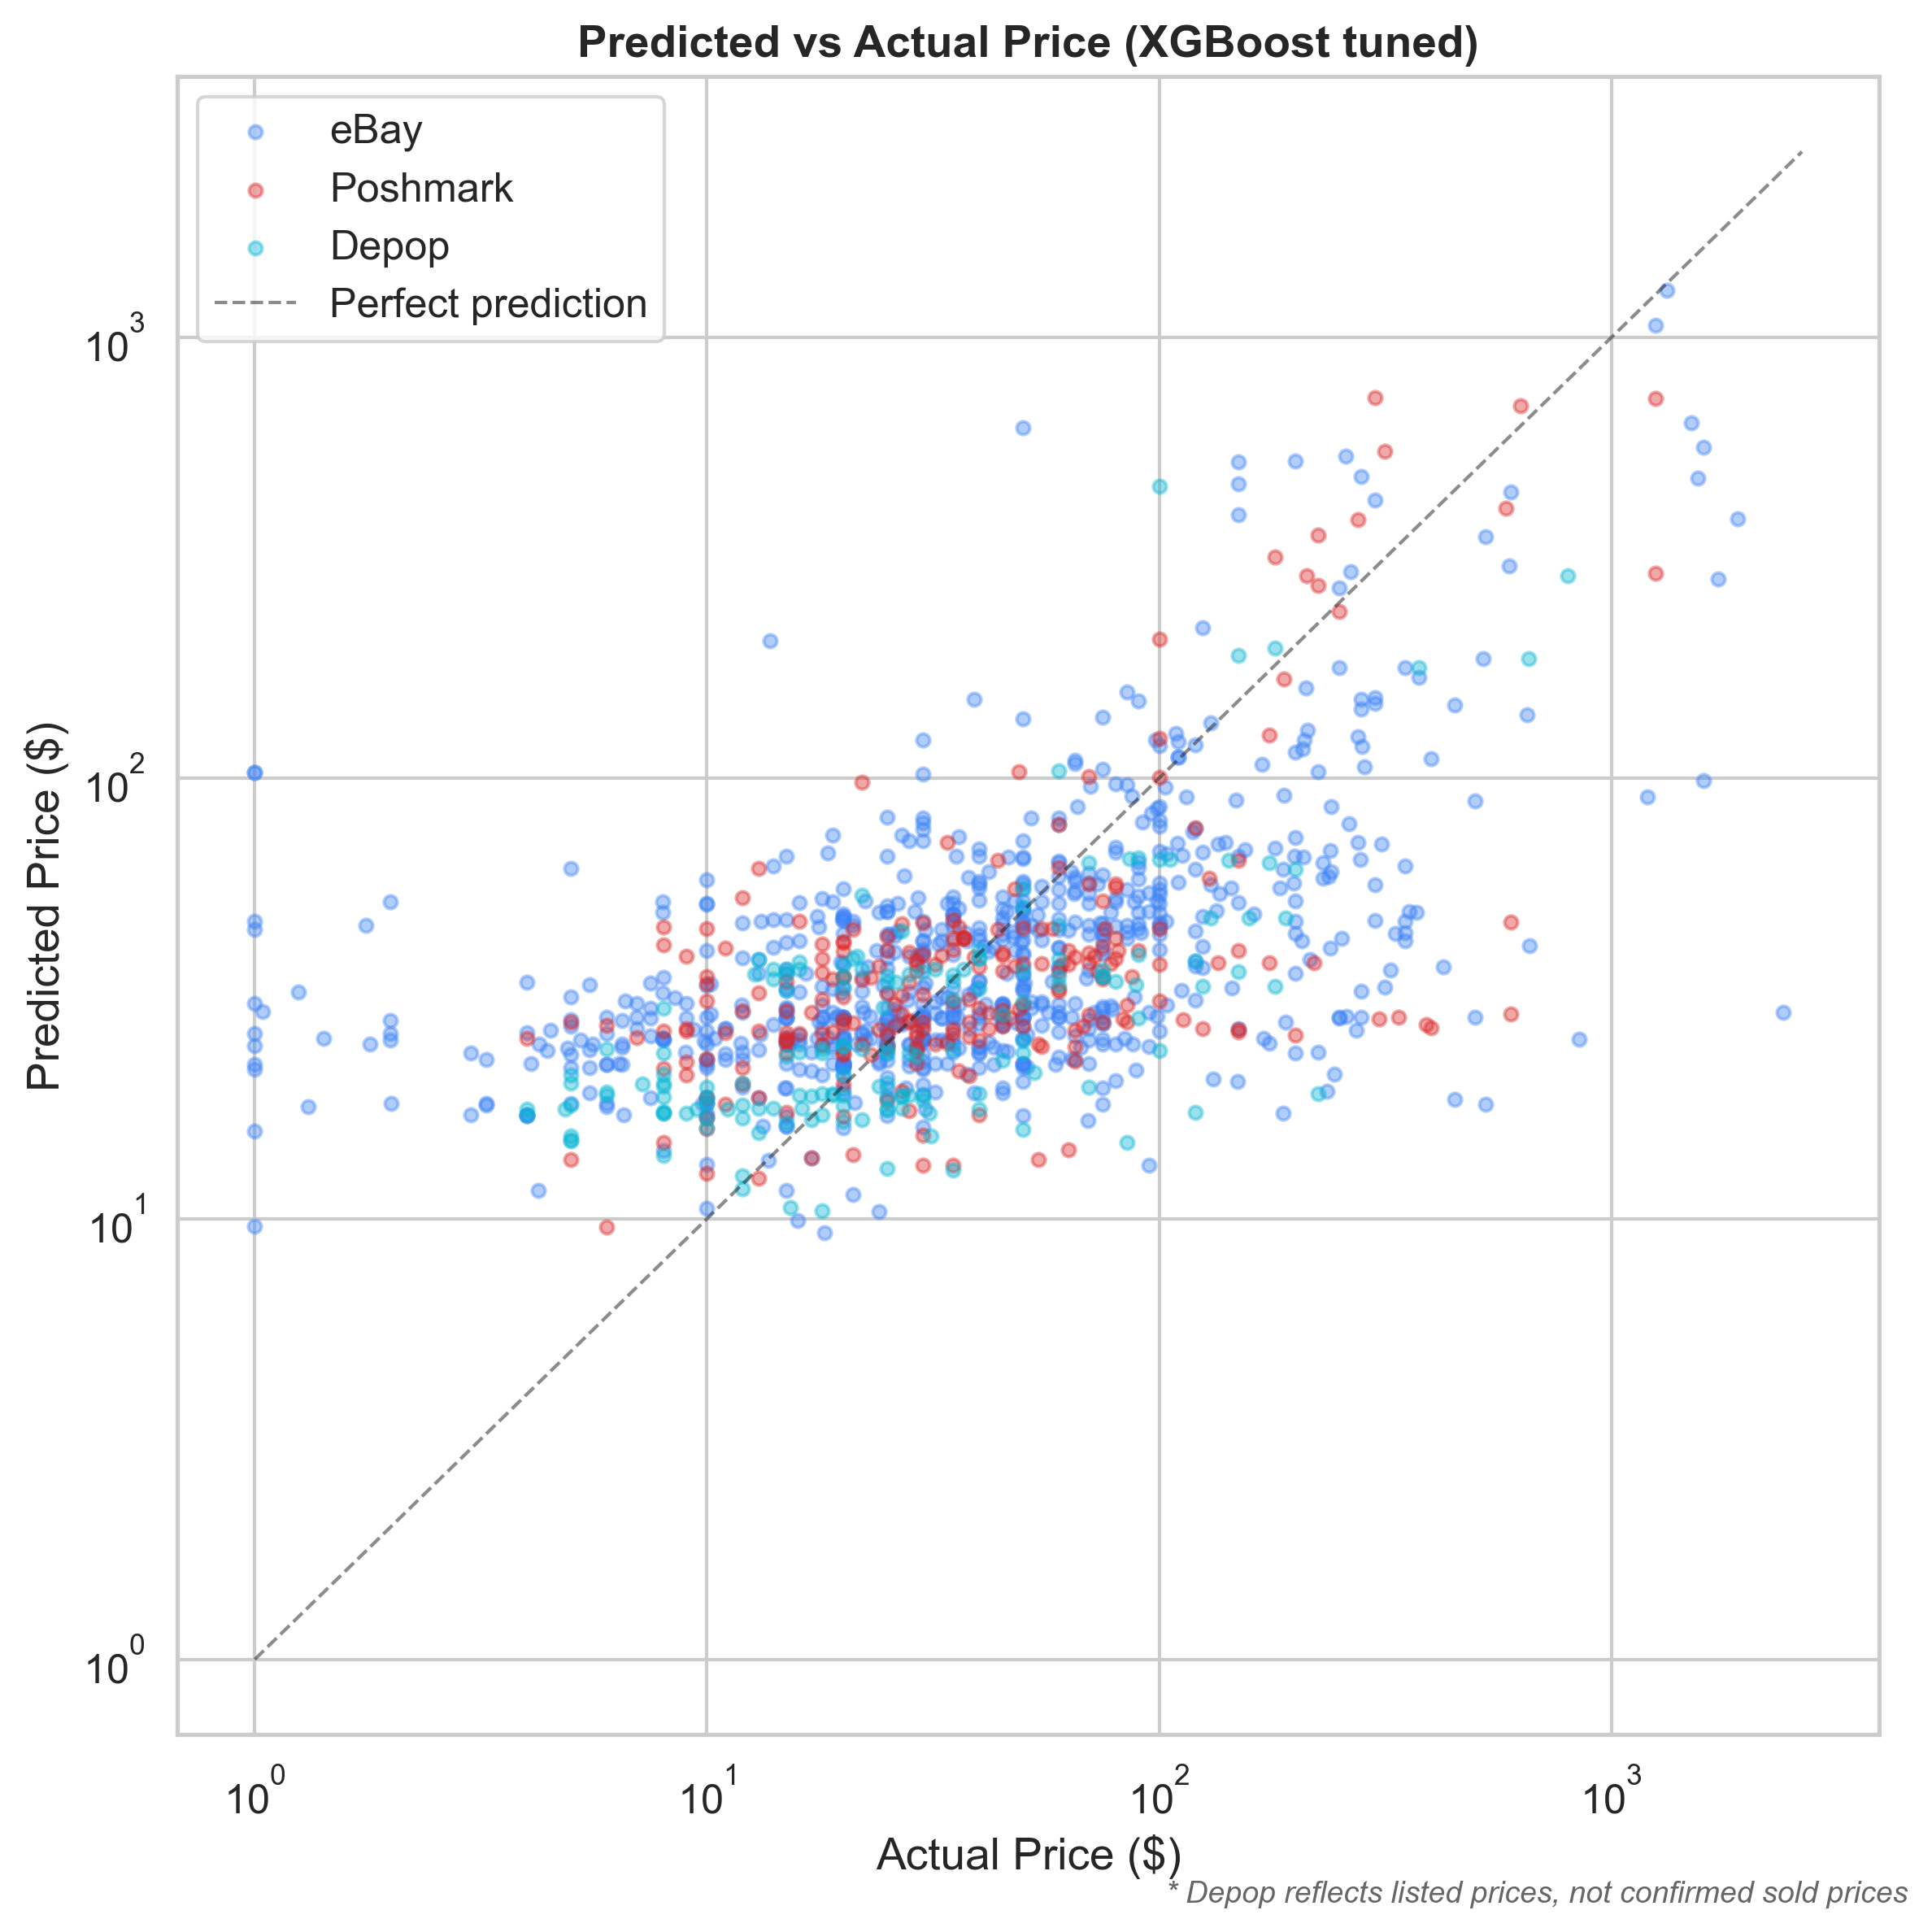

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

for plat in PLATFORM_ORDER:
    mask = test_eval["platform"] == plat
    ax.scatter(
        test_eval.loc[mask, "y_true"],
        test_eval.loc[mask, "y_pred"],
        alpha=0.4, s=15, label=plat, color=PLATFORM_COLORS[plat],
    )

lims = [1, test_eval[["y_true", "y_pred"]].max().max() * 1.1]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="Perfect prediction")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("Predicted vs Actual Price (XGBoost tuned)", fontweight="bold")
ax.legend()
add_depop_footnote(fig)
fig.tight_layout()
save_fig("predicted_vs_actual")

## Summary

In [12]:
import os

print("=== Polished Figures Generated ===")
print(f"Output directory: {FIGURES_DIR.resolve()}\n")

total_size = 0
for f in sorted(FIGURES_DIR.glob("*.png")):
    size_kb = f.stat().st_size / 1024
    total_size += size_kb
    print(f"  {f.name:<45} {size_kb:>7.0f} KB")

n_files = len(list(FIGURES_DIR.glob("*.png")))
print(f"\nTotal: {n_files} figures, {total_size:.0f} KB")
print(f"DPI: 300 (print quality)")
print(f"Palette: eBay {PLATFORM_COLORS['eBay']}, Poshmark {PLATFORM_COLORS['Poshmark']}, Depop {PLATFORM_COLORS['Depop']}")

=== Polished Figures Generated ===
Output directory: /Users/rabahbabaci/Developement/listIQ-BackEnd/notebooks/figures/final

  best_platform_heatmap.png                         233 KB
  dont_sell_by_platform.png                         156 KB
  feature_importance.png                            399 KB
  hourly_rate_distribution.png                      198 KB
  median_price_heatmap.png                          202 KB
  poshmark_velocity_by_category.png                 163 KB
  predicted_vs_actual.png                           559 KB
  price_by_platform_boxplots.png                    351 KB

Total: 8 figures, 2261 KB
DPI: 300 (print quality)
Palette: eBay #3B82F6, Poshmark #DC2626, Depop #06B6D4
